# Next-day Sales Forecasting for Daily Discount Decisions
## FreshRetailNet-50K: two baselines and five regression models

**Business goal.** Help a Dingdong category manager compare tomorrow's discount
options for a perishable SKU, using a sales forecast and a configurable business constraint.
**Experimental question.** On the same store–SKU series and later dates, which model
predicts next-day observed sales most accurately, and does target-day promotion information help?

This notebook contains the complete reproducible workflow: public data checks, cohort
selection, exploratory analysis, features, five-fold temporal validation, a final-period
comparison, promotion ablation, diagnostics, and an illustrative discount decision function.
The five models are **Ridge, Decision Tree, Random Forest, HistGradientBoosting and CatBoost**.
The **7-day average and same-weekday baselines appear first** in comparison tables.

**Scope and alignment.** The cohort rules, store counts, time windows, baseline scores and
discount-band counts reproduce the teammate report. Its preprocessing source was not supplied.
We therefore freeze an explicit 10-feature interpretation below, including a strictly lagged
expanding series mean. This is a report-based implementation, not a claim of identical source
code or an exact reproduction of the teammate's kNN scores. The earlier 100-series experiment
is backed up and is not mixed into these results.

**Data:** [Dingdong-Inc/FreshRetailNet-50K](https://huggingface.co/datasets/Dingdong-Inc/FreshRetailNet-50K),
CC BY 4.0, fixed revision `08c1fab7f9257bc73679d415d65d644165d351d4`.
Only existing public observations are used; no synthetic labels or inferred lost-demand labels
are created. `sale_amount` is normalized observed sales, not known item counts or currency.

**Run:** select a Python environment with `requirements-models.txt` installed, then
**Restart Kernel and Run All Cells**. Run from the repository root (the directory containing this notebook). Results are
written to `outputs/final_protocol/`. All experiment code is included in this repository; no hidden prior kernel state is needed.

## 1. Frozen experimental design

| Component | Decision fixed before the five-model run |
|---|---|
| Unit and target | One store–SKU–date; observed normalized `sale_amount` on that date |
| Cohort | Discount <0.95 on 15–85% of the 90 training days; ≥6 discount-state switches; zero sales on <20% of days; top five stores by qualifying series |
| Retained sample | Stores 343, 18, 235, 182, 154; 312 series, 122 products |
| History warm-up | March 28–April 3; first model-ready date April 4 |
| Validation | Five expanding-training folds: May 22–28, May 29–June 4, June 5–11, June 12–18, June 19–25 |
| Selection | Lowest mean validation MAE; three predeclared configurations per model and feature set |
| Final fit | Refit selected configurations once on April 4–June 25: 25,896 rows |
| Final-period benchmark | Official eval dates June 26–July 2: 2,184 identical rows for all methods |
| Metrics | MAE (primary), WAPE (%), MSE, RMSE; lower is better |
| Ablation | Remove target-day discount and activity together; retain historical promotion features; same tuning budget |
| Forecast timing | Rolling one day ahead; earlier observed days within a week update the next day's history; model parameters remain fixed within that week |

The whole 90-day training period is used to select the cohort, matching the report. This is a
**retrospectively selected sample** and uses later dates than early validation training windows.
The team has already viewed the official eval week in the teammate report; it is a shared final-period
benchmark, not a newly untouched holdout. No settings are changed in response to its scores.

Target-day discount and activity are assumed to be known planned inputs. Their advance availability
is not verified by the historical data. Weather is excluded, matching the final teammate design.
Target-day stockouts are used only for diagnostic groups. Observed sales under stockouts do not
identify unconstrained demand, and predictive gains do not establish causal pricing gains.

In [1]:
from __future__ import annotations
import os
for variable in ['OMP_NUM_THREADS', 'OPENBLAS_NUM_THREADS', 'MKL_NUM_THREADS']:
    os.environ[variable] = '4'
import gc, hashlib, json, platform, time
from datetime import datetime, timezone
from pathlib import Path
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
# Embed figures in notebook and HTML outputs, including headless Docker runs.
get_ipython().run_line_magic('matplotlib', 'inline')
import sklearn, catboost, joblib
from IPython.display import display, Markdown
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from catboost import CatBoostRegressor
from threadpoolctl import threadpool_limits

ROOT = Path.cwd()
assert (ROOT/'data/raw/train.parquet').exists(), 'Run from the group_project directory.'
OUT = ROOT/'outputs/final_protocol'
OUT.mkdir(parents=True, exist_ok=True)
SEED = 7002
np.random.seed(SEED)
KEYS = ['store_id', 'product_id']
ROW_KEYS = KEYS + ['dt']
REVISION = '08c1fab7f9257bc73679d415d65d644165d351d4'
HASHES = {'train': '6706832db892bbae4969c19d87e07975d2543d2ba7d7d4756360654785de5a3d',
          'eval': '1b118840664280c6b88bffc84c80ee1f54c05d911e354b7599e5da10995e960e'}
FOLDS = [(start, start + pd.Timedelta(days=6))
         for start in pd.date_range('2024-05-22', periods=5, freq='7D')]
MODELS = ['Ridge Regression', 'Decision Tree Regressor', 'Random Forest Regressor',
          'HistGradientBoostingRegressor', 'CatBoost Regressor']
BASELINES = {'7-day average baseline': 'sales_mean7',
             'Same-weekday baseline': 'sales_lag7'}
ORDER = list(BASELINES) + MODELS
BANDS = ['None/light (>0.95)', 'Moderate (0.80, 0.95]', 'Deep (<=0.80)']
METRICS = ['MAE', 'WAPE_pct', 'MSE', 'RMSE']
VERSIONS = {'python': platform.python_version(), 'numpy': np.__version__,
            'pandas': pd.__version__, 'scikit-learn': sklearn.__version__,
            'catboost': catboost.__version__, 'pyarrow': pa.__version__}
print('Environment:', VERSIONS)

def scores(y, pred):
    y, pred = np.asarray(y, dtype=float), np.asarray(pred, dtype=float)
    assert y.shape == pred.shape and y.size and np.isfinite(pred).all()
    err = pred-y
    mse = float(np.mean(err**2))
    denominator = float(np.abs(y).sum())
    return {'MAE': float(np.abs(err).mean()),
            'WAPE_pct': float(100*np.abs(err).sum()/denominator) if denominator else np.nan,
            'MSE': mse, 'RMSE': float(np.sqrt(mse)), 'n': int(len(y))}

def predict(model, frame, features):
    return np.maximum(0.0, np.asarray(model.predict(frame[features]), dtype=float))

def discount_bands(values):
    # Right-closed boundaries reproduce the report's 1,186 / 757 / 241 counts.
    return pd.cut(values, [-np.inf, .80, .95, np.inf],
                  labels=BANDS[::-1], right=True)

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

Environment: {'python': '3.11.14', 'numpy': '2.1.3', 'pandas': '2.2.3', 'scikit-learn': '1.6.1', 'catboost': '1.2.10', 'pyarrow': '19.0.0'}


## 2. Verify public files and reproduce the cohort

The SHA-256 checks pin the source observations. The incomplete `.part` download, if present,
is ignored. A change from the first day's missing predecessor is **not** a discount-state switch.
Rules are applied to each complete 90-day series before choosing the five stores. Eligibility
is calculated using `discount < 0.95`; evaluation band boundaries below are a separate convention.

The reported aggregates and baseline scores can be verified. Without the teammate's own ID
list, they are evidence of matching reconstruction rather than independent proof of identical IDs.

In [2]:
for split, expected_hash in HASHES.items():
    path = ROOT/f'data/raw/{split}.parquet'
    if not path.exists():
        raise FileNotFoundError(f'Download {split}.parquet from the fixed Hugging Face revision {REVISION}.')
    with path.open('rb') as handle:
        actual_hash = hashlib.file_digest(handle, 'sha256').hexdigest()
    assert actual_hash == expected_hash, f'{split} source hash mismatch'

selection_source = pd.read_parquet(ROOT/'data/raw/train.parquet',
    columns=KEYS+['dt', 'sale_amount', 'discount'])
selection_source = selection_source.sort_values(ROW_KEYS)
selection_source['discounted'] = selection_source.discount.lt(.95)
selection_source['zero'] = selection_source.sale_amount.eq(0)
previous = selection_source.groupby(KEYS, sort=False).discounted.shift()
selection_source['switch'] = previous.notna() & selection_source.discounted.ne(previous)
eligibility = selection_source.groupby(KEYS).agg(
    days=('dt', 'nunique'), discounted_fraction=('discounted', 'mean'),
    zero_fraction=('zero', 'mean'), switches=('switch', 'sum'))
assert eligibility.days.eq(90).all()
eligible = eligibility.loc[eligibility.discounted_fraction.between(.15, .85) &
    eligibility.zero_fraction.lt(.20) & eligibility.switches.ge(6)].reset_index()
assert len(eligible) == 16684
store_counts = eligible.groupby('store_id').size().sort_values(ascending=False)
selected_stores = store_counts.head(5).index.tolist()
assert set(selected_stores) == {343, 18, 235, 182, 154}
selected = eligible.loc[eligible.store_id.isin(selected_stores)].sort_values(KEYS).reset_index(drop=True)
assert len(selected) == 312 and selected.product_id.nunique() == 122
assert selected.groupby('store_id').size().to_dict() == {18:64, 154:60, 182:61, 235:63, 343:64}
selected.to_csv(OUT/'selected_series.csv', index=False)
cohort_table = selected.groupby('store_id').agg(series=('product_id', 'size')).reindex([343,18,235,182,154])
display(cohort_table)
del selection_source, previous, eligibility, eligible
gc.collect()

columns = ['city_id']+KEYS+['dt','sale_amount','discount','holiday_flag','activity_flag','stock_hour6_22_cnt']
parts = []
for split in ['train', 'eval']:
    for batch in pq.ParquetFile(ROOT/f'data/raw/{split}.parquet').iter_batches(
            batch_size=250_000, columns=columns):
        part = batch.to_pandas().merge(selected[KEYS], on=KEYS, validate='many_to_one')
        if len(part):
            part['source_split'] = split
            parts.append(part)
daily = pd.concat(parts, ignore_index=True)
daily['dt'] = pd.to_datetime(daily.dt)
daily = daily.sort_values(ROW_KEYS).reset_index(drop=True)
assert not daily.duplicated(ROW_KEYS).any() and not daily[columns].isna().any().any()
assert daily.groupby(KEYS).size().eq(97).all()
assert daily.groupby(KEYS).dt.diff().dropna().eq(pd.Timedelta(days=1)).all()
assert daily.city_id.eq(0).all() and daily.sale_amount.ge(0).all()
assert daily.discount.between(0,1,inclusive='right').all()
daily.to_parquet(OUT/'selected_daily_observations.parquet', index=False)
print(f'{len(daily):,} public observed rows; {len(selected)} store–SKU series; no missing dates.')

,series
store_id,
343,64
18,64
235,63
182,61
154,60


30,264 public observed rows; 312 store–SKU series; no missing dates.


## 3. Exploratory analysis on the training source

We describe only the selected training observations here. A higher mean on discounted days is
an association: discounts may be scheduled in response to expected demand, holidays or stock.
Stockout days are retained because the target is observed sales. We do not fill in hypothetical sales.

,series,stores,products,rows,first_date,last_date,mean_normalized_sales,zero_sales_pct,days_with_stockout_pct
0,312,5,122,28080,2024-03-28,2024-06-25,0.863,1.998,44.769


,rows,mean_sales,median_sales
discount_band,,,
None/light (>0.95),15720,0.688,0.5
"Moderate (0.80, 0.95]",9429,0.934,0.8
Deep (<=0.80),2931,1.571,1.2


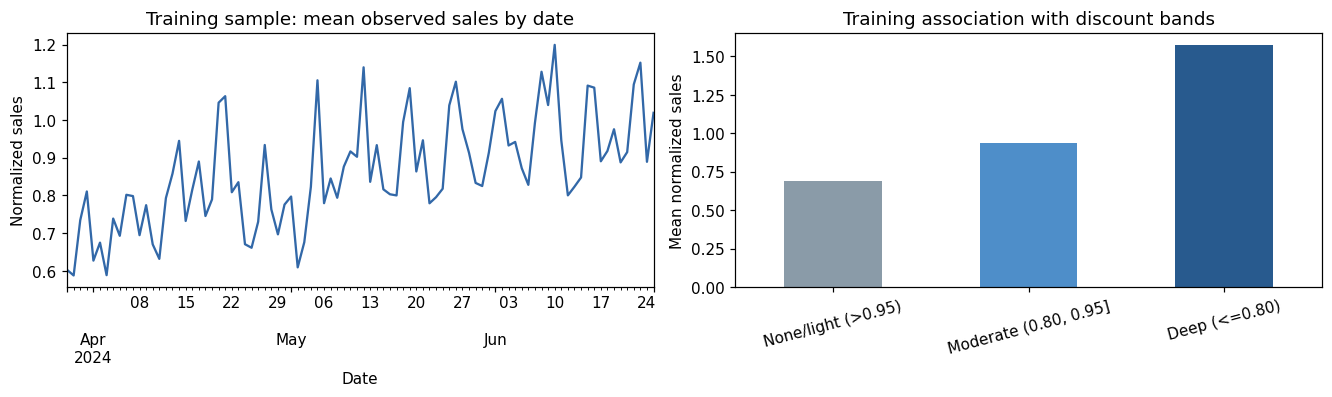

In [3]:
eda = daily.loc[daily.source_split.eq('train')].copy()
eda['discount_band'] = discount_bands(eda.discount)
eda_summary = pd.DataFrame([{
    'series': len(selected), 'stores': eda.store_id.nunique(), 'products': eda.product_id.nunique(),
    'rows': len(eda), 'first_date': str(eda.dt.min().date()), 'last_date': str(eda.dt.max().date()),
    'mean_normalized_sales': eda.sale_amount.mean(),
    'zero_sales_pct': 100*eda.sale_amount.eq(0).mean(),
    'days_with_stockout_pct': 100*eda.stock_hour6_22_cnt.gt(0).mean()}])
display(eda_summary.round(3))
eda_bands = eda.groupby('discount_band', observed=True).agg(
    rows=('sale_amount','size'), mean_sales=('sale_amount','mean'),
    median_sales=('sale_amount','median')).reindex(BANDS)
display(eda_bands.round(3))
eda_summary.to_csv(OUT/'data_summary.csv', index=False)
eda_bands.to_csv(OUT/'training_discount_summary.csv')
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5), constrained_layout=True)
eda.groupby('dt').sale_amount.mean().plot(ax=axes[0], color='#3268A8')
axes[0].set(title='Training sample: mean observed sales by date', ylabel='Normalized sales', xlabel='Date')
eda_bands.mean_sales.plot.bar(ax=axes[1], color=['#8A9BA8','#4E8EC9','#285A8E'])
axes[1].set(title='Training association with discount bands', ylabel='Mean normalized sales', xlabel='')
axes[1].tick_params(axis='x', rotation=15)
fig.savefig(OUT/'data_overview.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Ten input variables and leakage checks

The target date is the date being predicted. History always ends before that date.

| Feature | Definition / availability |
|---|---|
| `discount` | Target-day planned discount rate; a scenario input |
| `weekday` | Target-day weekday, Monday=0 to Sunday=6 |
| `holiday_flag` | Target-day calendar flag |
| `activity_flag` | Target-day planned activity flag |
| `sales_lag1` | Sales one calendar day earlier |
| `sales_lag7` | Sales seven calendar days earlier |
| `sales_mean7` | Mean of sales on the preceding seven days |
| `discount_lag1` | Previous day's discount |
| `stockout_lag1` | Previous day's recorded stockout hours |
| `series_mean` | Expanding mean of all earlier observed sales for this store–SKU, including warm-up dates |

The expanding mean is computed row by row using past observations, rather than a whole-dataset
or whole-fold target mean. No store, SKU or category ID is fed to a model. Weekday remains numeric
for the common report-based representation; alternative encodings are outside this frozen run.
There are no weather predictors. The ablation removes `discount` and `activity_flag` only.

In [4]:
FEATURES = ['discount','weekday','holiday_flag','activity_flag',
            'sales_lag1','sales_lag7','sales_mean7','discount_lag1','stockout_lag1','series_mean']
FEATURE_SETS = {'full': FEATURES,
                'without_target_promotion': [c for c in FEATURES if c not in ['discount','activity_flag']]}

def make_features(frame):
    frame = frame.sort_values(ROW_KEYS).copy()
    g = frame.groupby(KEYS, sort=False)
    frame['weekday'] = frame.dt.dt.dayofweek
    frame['sales_lag1'] = g.sale_amount.shift(1)
    frame['sales_lag7'] = g.sale_amount.shift(7)
    frame['sales_mean7'] = g.sale_amount.transform(lambda s: s.shift(1).rolling(7, min_periods=7).mean())
    frame['discount_lag1'] = g.discount.shift(1)
    frame['stockout_lag1'] = g.stock_hour6_22_cnt.shift(1)
    frame['series_mean'] = g.sale_amount.transform(lambda s: s.shift(1).expanding(min_periods=1).mean())
    return frame

featured = make_features(daily)
cutoff = pd.Timestamp('2024-06-08')
prefix = make_features(daily.loc[daily.dt.le(cutoff)])
pd.testing.assert_frame_equal(featured.loc[featured.dt.le(cutoff), FEATURES], prefix[FEATURES])
# A target day's outcome must not influence any predictor for that date.
changed = daily.copy()
changed.loc[changed.dt.eq(cutoff), ['sale_amount','stock_hour6_22_cnt']] = 999
changed_features = make_features(changed)
pd.testing.assert_frame_equal(featured.loc[featured.dt.eq(cutoff), FEATURES],
                              changed_features.loc[changed_features.dt.eq(cutoff), FEATURES])
frame = featured.dropna(subset=FEATURES).sort_values(['dt']+KEYS).reset_index(drop=True)
assert np.isfinite(frame[FEATURES].to_numpy()).all()
assert not {'sale_amount','stock_hour6_22_cnt','city_id','store_id','product_id'} & set(FEATURES)
frame['discount_band'] = discount_bands(frame.discount)
train = frame.loc[frame.source_split.eq('train')].copy()
test = frame.loc[frame.source_split.eq('eval')].copy()
assert len(train) == 25896 and len(test) == 2184
assert train.dt.min() == pd.Timestamp('2024-04-04') and train.dt.max() == pd.Timestamp('2024-06-25')
assert test.dt.min() == pd.Timestamp('2024-06-26') and test.dt.max() == pd.Timestamp('2024-07-02')
assert test.groupby('discount_band', observed=True).size().reindex(BANDS).tolist() == [1186,757,241]
frame.to_parquet(OUT/'feature_frame.parquet', index=False)
fold_rows = []
for fold, (start, end) in enumerate(FOLDS, 1):
    tr, va = train.loc[train.dt.lt(start)], train.loc[train.dt.between(start,end)]
    assert len(va) == 2184 and tr.dt.max() < va.dt.min()
    fold_rows.append({'fold':fold, 'train_start':str(tr.dt.min().date()),
        'train_end':str(tr.dt.max().date()), 'valid_start':str(start.date()),
        'valid_end':str(end.date()), 'n_train':len(tr), 'n_valid':len(va)})
fold_table = pd.DataFrame(fold_rows)
display(fold_table)
fold_table.to_csv(OUT/'folds.csv', index=False)
print('Passed: row/date checks, warm-up counts, prefix invariance and current-outcome leakage check.')

,fold,train_start,train_end,valid_start,valid_end,n_train,n_valid
0,1,2024-04-04,2024-05-21,2024-05-22,2024-05-28,14976,2184
1,2,2024-04-04,2024-05-28,2024-05-29,2024-06-04,17160,2184
2,3,2024-04-04,2024-06-04,2024-06-05,2024-06-11,19344,2184
3,4,2024-04-04,2024-06-11,2024-06-12,2024-06-18,21528,2184
4,5,2024-04-04,2024-06-18,2024-06-19,2024-06-25,23712,2184


Passed: row/date checks, warm-up counts, prefix invariance and current-outcome leakage check.


## 5. Baselines and model definitions

| Method | Role and fitting approach |
|---|---|
| 7-day average baseline | Primary benchmark: trailing seven observed days, no fitted parameters |
| Same-weekday baseline | Secondary benchmark: actual sales seven days earlier |
| Ridge Regression | Regularized linear relationship; training-only standardization |
| Decision Tree Regressor | Interpretable nonlinear splits; depth and leaf-size controls |
| Random Forest Regressor | Average of randomized trees; depth and leaf-size controls |
| HistGradientBoostingRegressor | Sequential boosted trees using histogram splits |
| CatBoost Regressor | Boosted trees; numeric inputs in this shared feature design |

All fitted models predict the original target with squared-error/RMSE fitting objectives.
All predictions are clipped at zero before scoring. Trees use the raw numeric features;
Ridge's scaler is fitted separately inside each training fold. There is no feature weighting,
log target, test-based early stopping or monotonicity constraint in this comparison.
The modest grid has three configurations per model per feature set, not exhaustive tuning.

In [5]:
GRIDS = {
    'Ridge Regression': [{'alpha': a} for a in [.1,10.,100.]],
    'Decision Tree Regressor': [dict(max_depth=4,min_samples_leaf=20),
        dict(max_depth=8,min_samples_leaf=20), dict(max_depth=12,min_samples_leaf=40)],
    'Random Forest Regressor': [dict(n_estimators=200,max_depth=10,min_samples_leaf=5),
        dict(n_estimators=200,max_depth=None,min_samples_leaf=5),
        dict(n_estimators=200,max_depth=None,min_samples_leaf=15)],
    'HistGradientBoostingRegressor': [dict(max_iter=300,learning_rate=.05,max_leaf_nodes=15),
        dict(max_iter=300,learning_rate=.05,max_leaf_nodes=31),
        dict(max_iter=500,learning_rate=.03,max_leaf_nodes=15)],
    'CatBoost Regressor': [dict(iterations=400,depth=d,learning_rate=.05,l2_leaf_reg=5) for d in [4,6,8]]}

def build_model(name, params):
    if name == 'Ridge Regression':
        return make_pipeline(StandardScaler(), Ridge(**params))
    if name == 'Decision Tree Regressor':
        return DecisionTreeRegressor(**params, random_state=SEED)
    if name == 'Random Forest Regressor':
        return RandomForestRegressor(**params, max_features=.8, random_state=SEED, n_jobs=4)
    if name == 'HistGradientBoostingRegressor':
        return HistGradientBoostingRegressor(**params, l2_regularization=1.,
                    early_stopping=False, random_state=SEED)
    if name == 'CatBoost Regressor':
        return CatBoostRegressor(**params, loss_function='RMSE', random_seed=SEED,
                    has_time=True, thread_count=4, verbose=False, allow_writing_files=False)
    raise ValueError(name)

locked_protocol = {'seed':SEED, 'data_revision':REVISION, 'source_hashes':HASHES,
    'cohort_series':312, 'cohort_selection_through':'2024-06-25',
    'features':FEATURE_SETS, 'series_mean':'shift(1).expanding mean including raw warm-up dates',
    'weekday':'integer Monday=0 through Sunday=6', 'grids':GRIDS,
    'folds':fold_table.to_dict('records'), 'selection_metric':'mean of five weekly validation MAEs',
    'forecast_protocol':'rolling one day ahead; prior observed days update features; no within-week model refit',
    'test_period':['2024-06-26','2024-07-02'], 'test_previously_viewed_by_team':True,
    'prediction_postprocessing':'clip at zero',
    'alignment':'report-based reconstruction; teammate preprocessing source unavailable',
    'scenario_demo':{'maximum_proxy_loss':.05,'minimum_same_series_activity_rate_support':3,
                     'discount_rounding_decimals':2,'decision_metric':'predicted normalized sales'}}
(OUT/'locked_protocol.json').write_text(json.dumps(locked_protocol, indent=2)+'\n')
baseline_folds = []
for fold, (start,end) in enumerate(FOLDS,1):
    va = train.loc[train.dt.between(start,end)]
    for name,col in BASELINES.items():
        baseline_folds.append({'fold':fold,'Model':name,**scores(va.sale_amount,va[col])})
baseline_cv = pd.DataFrame(baseline_folds)
baseline_cv.to_csv(OUT/'baseline_validation_folds.csv', index=False)
baseline_cv_mean = baseline_cv.groupby('Model', sort=False)[METRICS].mean().reindex(BASELINES)
assert round(baseline_cv_mean.loc['7-day average baseline','MAE'],3) == .328
display(baseline_cv_mean.round(4))

,MAE,WAPE_pct,MSE,RMSE
Model,,,,
7-day average baseline,0.3284,34.4701,0.2701,0.5176
Same-weekday baseline,0.4150,43.5748,0.4408,0.6610


## 6. Tune on the same five weekly folds

Each candidate is fitted from scratch on dates preceding the validation week. Every candidate
is scored on the same 2,184 rows per fold. We average the five weekly MAEs to select parameters;
ties are resolved by the predeclared candidate order. WAPE and RMSE in the CV table are also
means of weekly metrics, which need not equal their pooled-row versions.

The full-feature model with the lowest mean validation MAE is the selected forecasting model.
The ablation is selected separately with the same budget. No final-period model ranking enters selection.

In [6]:
trials = []
for feature_set, features in FEATURE_SETS.items():
    for name in MODELS:
        for candidate, params in enumerate(GRIDS[name]):
            t0 = time.perf_counter()
            for fold, (start,end) in enumerate(FOLDS,1):
                tr, va = train.loc[train.dt.lt(start)], train.loc[train.dt.between(start,end)]
                model = build_model(name, params)
                with threadpool_limits(limits=4):
                    model.fit(tr[features], tr.sale_amount)
                    pred = predict(model, va, features)
                trials.append({'feature_set':feature_set,'Model':name,'candidate':candidate,
                    'parameters':json.dumps(params,sort_keys=True),'fold':fold,
                    'n_train':len(tr), **scores(va.sale_amount,pred)})
            recent_mae = np.mean([r['MAE'] for r in trials[-5:]])
            print(f'{feature_set:25s} | {name:29s} | candidate {candidate}: '
                  f'CV MAE {recent_mae:.4f} ({time.perf_counter()-t0:.1f}s)', flush=True)
            pd.DataFrame(trials).to_csv(OUT/'validation_trials.csv', index=False)

trial_table = pd.DataFrame(trials)
assert len(trial_table) == 2*5*3*5
cv_summary = trial_table.groupby(['feature_set','Model','candidate','parameters'],sort=False).agg(
    MAE=('MAE','mean'), MAE_std=('MAE','std'), WAPE_pct=('WAPE_pct','mean'),
    MSE=('MSE','mean'), RMSE=('RMSE','mean'), n_folds=('fold','nunique')).reset_index()
assert cv_summary.n_folds.eq(5).all()
best = cv_summary.sort_values(['MAE','candidate'],kind='stable').drop_duplicates(['feature_set','Model'])
chosen = {(r.feature_set,r.Model):json.loads(r.parameters) for r in best.itertuples()}
selected_name = best.loc[best.feature_set.eq('full')].sort_values('MAE').iloc[0].Model
cv_summary.to_csv(OUT/'validation_candidates.csv', index=False)
best.to_csv(OUT/'chosen_parameters.csv', index=False)
display(best[['feature_set','Model','MAE','MAE_std','WAPE_pct','parameters']].round(4))
print('Validation-selected full-feature model:', selected_name)
selection_record = {'selected_by_validation':selected_name,
    'parameters':{f'{fs}::{name}':params for (fs,name),params in chosen.items()},
    'selection_rule':'lowest mean five-fold MAE, before final-period scoring'}
(OUT/'selection_before_test.json').write_text(json.dumps(selection_record,indent=2)+'\n')

full                      | Ridge Regression              | candidate 0: CV MAE 0.3154 (0.0s)


full                      | Ridge Regression              | candidate 1: CV MAE 0.3154 (0.0s)


full                      | Ridge Regression              | candidate 2: CV MAE 0.3151 (0.0s)


full                      | Decision Tree Regressor       | candidate 0: CV MAE 0.3428 (0.1s)


full                      | Decision Tree Regressor       | candidate 1: CV MAE 0.3218 (0.2s)


...

without_target_promotion  | CatBoost Regressor            | candidate 1: CV MAE 0.3205 (2.1s)


without_target_promotion  | CatBoost Regressor            | candidate 2: CV MAE 0.3233 (3.6s)


,feature_set,Model,MAE,MAE_std,WAPE_pct,parameters
6,full,Random Forest Regressor,0.3037,0.0210,31.8676,"{""max_depth"": 10, ""min_samples_leaf"": 5, ""n_es..."
12,full,CatBoost Regressor,0.3038,0.0187,31.8827,"{""depth"": 4, ""iterations"": 400, ""l2_leaf_reg"":..."
9,full,HistGradientBoostingRegressor,0.3055,0.0192,32.0591,"{""learning_rate"": 0.05, ""max_iter"": 300, ""max_..."
2,full,Ridge Regression,0.3151,0.0161,33.0762,"{""alpha"": 100.0}"
23,without_target_promotion,Random Forest Regressor,0.3191,0.0270,33.4728,"{""max_depth"": null, ""min_samples_leaf"": 15, ""n..."
27,without_target_promotion,CatBoost Regressor,0.3201,0.0297,33.5717,"{""depth"": 4, ""iterations"": 400, ""l2_leaf_reg"":..."
15,without_target_promotion,Ridge Regression,0.3212,0.0218,33.7077,"{""alpha"": 0.1}"
4,full,Decision Tree Regressor,0.3218,0.0171,33.7790,"{""max_depth"": 8, ""min_samples_leaf"": 20}"
26,without_target_promotion,HistGradientBoostingRegressor,0.3230,0.0304,33.8691,"{""learning_rate"": 0.03, ""max_iter"": 500, ""max_..."
19,without_target_promotion,Decision Tree Regressor,0.3336,0.0247,35.0035,"{""max_depth"": 8, ""min_samples_leaf"": 20}"


Validation-selected full-feature model: Random Forest Regressor


1355

## 7. Refit once and evaluate the final period

Refit each chosen configuration on all 25,896 training rows. Predict all 2,184 final-period
rows, with the same feature timing and without model updates during the week. We report all
five models even if a baseline is better. Improvements below are relative error reductions,
not changes in sales, revenue or classification accuracy.

In [7]:
predictions = test[ROW_KEYS+['sale_amount','discount','activity_flag','stock_hour6_22_cnt','discount_band']].copy()
rows, fitted = [], {}
for name,col in BASELINES.items():
    predictions[name] = test[col].to_numpy()
    rows.append({'feature_set':'baseline','Model':name,'fit_seconds':0.,
                 **scores(test.sale_amount,predictions[name])})
for feature_set, features in FEATURE_SETS.items():
    for name in MODELS:
        t0 = time.perf_counter()
        model = build_model(name, chosen[(feature_set,name)])
        with threadpool_limits(limits=4):
            model.fit(train[features], train.sale_amount)
            pred = predict(model,test,features)
        fitted[(feature_set,name)] = model
        predictions[f'{feature_set}::{name}'] = pred
        rows.append({'feature_set':feature_set,'Model':name,
                     'fit_seconds':time.perf_counter()-t0,**scores(test.sale_amount,pred)})
        print(f'Refitted {feature_set} / {name}',flush=True)
all_scores = pd.DataFrame(rows)
comparison = (all_scores.loc[all_scores.feature_set.isin(['baseline','full'])]
              .set_index('Model').reindex(ORDER).reset_index())
baseline_mae = comparison.loc[0,'MAE']
comparison['MAE_improvement_vs_7day_pct'] = 100*(1-comparison.MAE/baseline_mae)
comparison['selected_by_validation'] = comparison.Model.eq(selected_name)
assert round(baseline_mae,3) == .314
assert round(comparison.loc[1,'MAE'],3) == .400
comparison.to_csv(OUT/'model_comparison_test.csv', index=False)
all_scores.to_csv(OUT/'all_test_scores.csv', index=False)
predictions.to_csv(OUT/'test_predictions.csv', index=False)
display(comparison[['Model']+METRICS+['MAE_improvement_vs_7day_pct','selected_by_validation']].round(4))
joblib.dump({'model':fitted[('full',selected_name)],'features':FEATURES,
             'selected_name':selected_name,'versions':VERSIONS,'protocol':locked_protocol},
             OUT/'selected_forecast_model.joblib')
print('Saved row-level predictions and the validation-selected fitted model.')

Refitted full / Ridge Regression


Refitted full / Decision Tree Regressor


Refitted full / Random Forest Regressor


Refitted full / HistGradientBoostingRegressor


Refitted full / CatBoost Regressor


...

Refitted without_target_promotion / Random Forest Regressor


Refitted without_target_promotion / HistGradientBoostingRegressor


Refitted without_target_promotion / CatBoost Regressor


,Model,MAE,WAPE_pct,MSE,RMSE,MAE_improvement_vs_7day_pct,selected_by_validation
0,7-day average baseline,0.3142,32.4360,0.2713,0.5209,0.0000,False
1,Same-weekday baseline,0.3998,41.2699,0.3808,0.6171,-27.2348,False
2,Ridge Regression,0.3075,31.7500,0.2531,0.5031,2.1148,False
3,Decision Tree Regressor,0.3139,32.4102,0.2438,0.4938,0.0796,False
4,Random Forest Regressor,0.2929,30.2436,0.2141,0.4627,6.7590,True
5,HistGradientBoostingRegressor,0.2892,29.8541,0.2063,0.4543,7.9600,False
6,CatBoost Regressor,0.2878,29.7118,0.2042,0.4519,8.3988,False


Saved row-level predictions and the validation-selected fitted model.


## 8. Do promotion inputs improve prediction?

Compare the full feature set against removing target-day discount and activity together.
Both variants were tuned independently on the same folds and grid size. Positive improvement
means the full variant has lower MAE. This checks their joint predictive usefulness, not the
causal effect of discounting or the separate contribution of each input.

In [8]:
ablation = all_scores.loc[all_scores.feature_set.ne('baseline')].pivot(
    index='Model',columns='feature_set',values='MAE').reindex(MODELS)
ablation.columns.name = None
ablation['test_MAE_improvement_with_promotion_pct'] = 100*(1-ablation.full/ablation.without_target_promotion)
cv_ablation = best.pivot(index='Model',columns='feature_set',values='MAE')
ablation['CV_full_MAE'] = cv_ablation['full']
ablation['CV_without_promotion_MAE'] = cv_ablation['without_target_promotion']
ablation = ablation.reset_index()
ablation.to_csv(OUT/'promotion_ablation_test.csv',index=False)
display(ablation.round(4))

,Model,full,without_target_promotion,test_MAE_improvement_with_promotion_pct,CV_full_MAE,CV_without_promotion_MAE
0,Ridge Regression,0.3075,0.3084,0.2923,0.3151,0.3212
1,Decision Tree Regressor,0.3139,0.3216,2.3848,0.3218,0.3336
2,Random Forest Regressor,0.2929,0.3106,5.6854,0.3037,0.3191
3,HistGradientBoostingRegressor,0.2892,0.3079,6.0816,0.3055,0.3230
4,CatBoost Regressor,0.2878,0.3010,4.3822,0.3038,0.3201


## 9. Where do models win or lose?

Overall accuracy can hide errors on the discount days that matter for the decision. We
therefore report the same discount groups as the teammate's reported counts: **>0.95**,
**(0.80, 0.95]**, and **<=0.80**. The boundary observations belong to the lower-price group.
We also summarize by date, store and recorded target-day stockout status. These are diagnostics,
not new tuning objectives. Seven dates and a selected sample limit precision and generalizability.

In [9]:
slice_rows = []
groups = [('discount_band',band,predictions.discount_band.eq(band)) for band in BANDS]
groups += [('stockout','No recorded stockout',predictions.stock_hour6_22_cnt.eq(0)),
           ('stockout','Some recorded stockout',predictions.stock_hour6_22_cnt.gt(0))]
groups += [('date',str(d.date()),predictions.dt.eq(d)) for d in sorted(predictions.dt.unique())]
groups += [('store',str(s),predictions.store_id.eq(s)) for s in sorted(predictions.store_id.unique())]
for dimension,label,mask in groups:
    for name in ORDER:
        col = name if name in BASELINES else f'full::{name}'
        part = predictions.loc[mask]
        slice_rows.append({'dimension':dimension,'slice':label,'Model':name,
            'actual_mean':part.sale_amount.mean(),'predicted_mean':part[col].mean(),
            **scores(part.sale_amount,part[col])})
slice_scores = pd.DataFrame(slice_rows)
slice_scores.to_csv(OUT/'test_slice_scores.csv',index=False)
band_table = slice_scores.loc[slice_scores.dimension.eq('discount_band')].pivot(
    index='Model',columns='slice',values='MAE').reindex(index=ORDER,columns=BANDS)
display(band_table.round(4))
daily_scores = slice_scores.loc[slice_scores.dimension.eq('date')].pivot(index='slice',columns='Model',values='MAE')[ORDER]
daily_scores.to_csv(OUT/'daily_test_mae.csv')
cv_selected = trial_table.merge(best[['feature_set','Model','candidate']],
    on=['feature_set','Model','candidate'],how='inner',validate='many_to_one')
cv_full = cv_selected.loc[cv_selected.feature_set.eq('full')]
fold_benchmark = baseline_cv.loc[baseline_cv.Model.eq('7-day average baseline')].set_index('fold').MAE
fold_wins = cv_full.assign(beats_baseline=lambda d:d.MAE.lt(d.fold.map(fold_benchmark))).groupby('Model').beats_baseline.sum().reindex(MODELS)
display(fold_wins.rename('Validation folds beating 7-day baseline').to_frame())

slice,None/light (>0.95),"Moderate (0.80, 0.95]",Deep (<=0.80)
Model,,,
7-day average baseline,0.2711,0.3033,0.5606
Same-weekday baseline,0.3597,0.3800,0.6590
Ridge Regression,0.2437,0.3187,0.5868
Decision Tree Regressor,0.2582,0.3191,0.5721
Random Forest Regressor,0.2362,0.3026,0.5422
HistGradientBoostingRegressor,0.2344,0.2989,0.5282
CatBoost Regressor,0.2330,0.2949,0.5352


,Validation folds beating 7-day baseline
Model,
Ridge Regression,5
Decision Tree Regressor,5
Random Forest Regressor,5
HistGradientBoostingRegressor,5
CatBoost Regressor,5


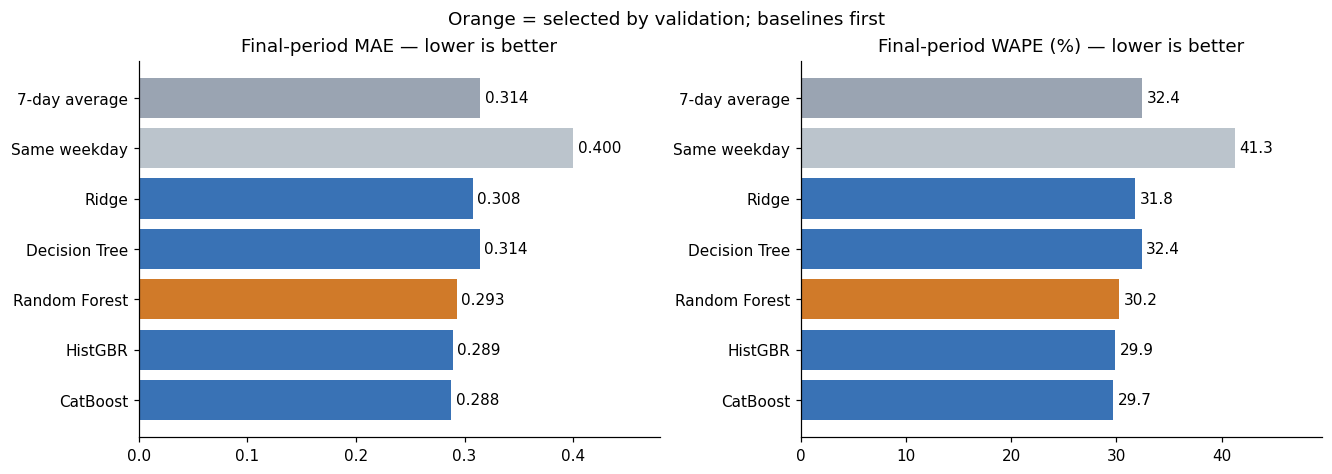

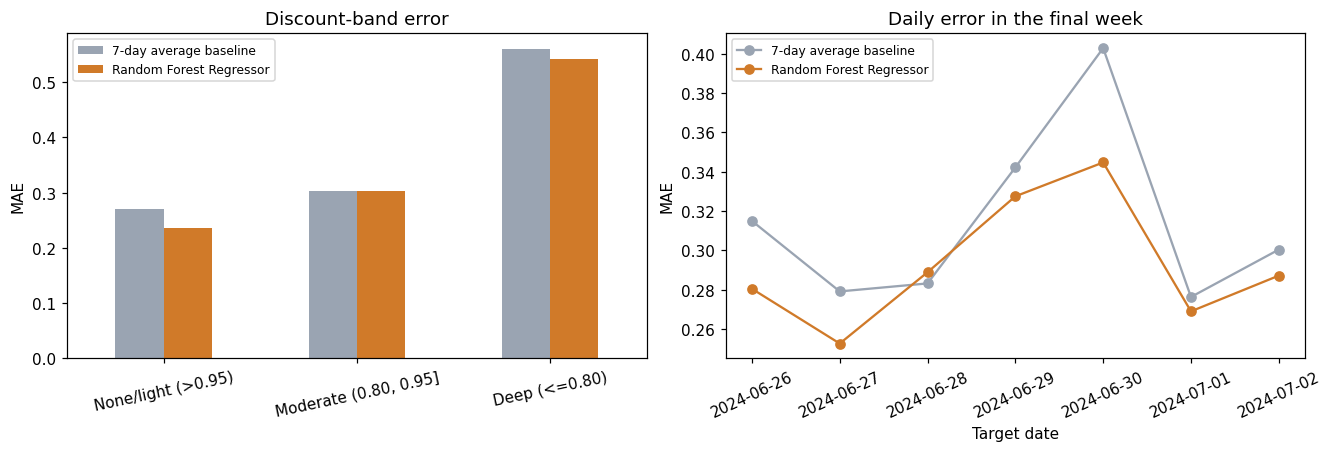

In [10]:
short_names = ['7-day average','Same weekday','Ridge','Decision Tree','Random Forest','HistGBR','CatBoost']
colors = ['#9AA4B2','#BBC4CC'] + ['#3972B5' if name != selected_name else '#D07A29' for name in MODELS]
fig, axes = plt.subplots(1,2,figsize=(12,4.2),constrained_layout=True)
for ax,metric,title in zip(axes,['MAE','WAPE_pct'],['Final-period MAE','Final-period WAPE (%)']):
    bars = ax.barh(short_names,comparison[metric],color=colors)
    ax.invert_yaxis()
    ax.bar_label(bars,fmt='%.3f' if metric=='MAE' else '%.1f',padding=3)
    ax.set(title=title+' — lower is better',xlim=(0,comparison[metric].max()*1.2))
    ax.spines[['top','right']].set_visible(False)
fig.suptitle('Orange = selected by validation; baselines first')
fig.savefig(OUT/'model_comparison.png',dpi=160,bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(1,2,figsize=(12,4),constrained_layout=True)
band_table.loc[['7-day average baseline',selected_name]].T.plot.bar(ax=axes[0],color=['#9AA4B2','#D07A29'])
axes[0].set(title='Discount-band error',xlabel='',ylabel='MAE')
axes[0].tick_params(axis='x',rotation=12)
axes[0].legend(fontsize=8)
daily_scores[['7-day average baseline',selected_name]].plot(ax=axes[1],marker='o',color=['#9AA4B2','#D07A29'])
axes[1].set(title='Daily error in the final week',xlabel='Target date',ylabel='MAE')
axes[1].tick_params(axis='x',rotation=25)
axes[1].legend(fontsize=8)
fig.savefig(OUT/'discount_and_daily_errors.png',dpi=160,bbox_inches='tight')
plt.show()

## 10. Illustrative discount scenario analysis

This optional application step uses the validation-selected forecast model. It does not evaluate
a deployed pricing policy. Holding the other scenario inputs fixed, compare supported historical
discount rates and choose the highest predicted sales subject to a proxy constraint.

For a candidate discount rate **d**, define a dimensionless **sales-value proxy** as
**d × predicted normalized sales**. Require that this proxy remains at least 95% of its value
at the reference rate. The 5% allowance is an illustrative business setting, not a learned optimum.
The dataset does not provide a verified base-price or normalization conversion: this proxy is
**not measured revenue**, and a 5% proxy change cannot be claimed as a 5% revenue change.

Candidate rates are rounded to two decimals and need at least three training observations for
the same store–SKU and activity state. The reference must also be supported. This reduces
unsupported extrapolation but does not remove confounding. We show one first-day scenario chosen
by history availability, not by forecast gains. Scenario outcomes under unchosen prices are not observed.
Inventory constraints, actual profit, waste reduction and causal policy validation require additional data.

In [11]:
def recommend_discount(context, reference_rate, training_history, model, max_proxy_loss=.05):
    if not 0 <= max_proxy_loss <= 1:
        raise ValueError('max_proxy_loss must be between 0 and 1')
    history = training_history.loc[
        training_history.store_id.eq(context['store_id']) &
        training_history.product_id.eq(context['product_id']) &
        training_history.activity_flag.eq(context['activity_flag']) &
        training_history.dt.lt(context['dt'])].copy()
    support = history.discount.round(2).value_counts()
    rates = sorted(float(r) for r in support.loc[support.ge(3)].index if 0 < r <= 1)
    reference_rate = round(float(reference_rate),2)
    if len(rates) < 2 or reference_rate not in rates:
        return None, 'Insufficient supported discount options for this store–SKU and activity state.'
    scenarios = pd.DataFrame([{**context,'discount':d} for d in rates])
    scenarios['predicted_sales'] = predict(model,scenarios,FEATURES)
    scenarios['sales_value_proxy'] = scenarios.discount * scenarios.predicted_sales
    reference_proxy = float(scenarios.loc[scenarios.discount.eq(reference_rate),'sales_value_proxy'].iloc[0])
    if reference_proxy <= 0:
        return None, 'Reference proxy is non-positive; a relative-loss constraint is undefined.'
    scenarios['relative_proxy_change_pct'] = 100*(scenarios.sales_value_proxy/reference_proxy-1)
    scenarios['supported_training_days'] = scenarios.discount.map(support).astype(int)
    scenarios['feasible'] = scenarios.sales_value_proxy.ge((1-max_proxy_loss)*reference_proxy-1e-12)
    chosen_scenario = scenarios.loc[scenarios.feasible].sort_values(
        ['predicted_sales','discount'],ascending=[False,False]).iloc[0]
    scenarios['recommended'] = scenarios.discount.eq(chosen_scenario.discount)
    return scenarios[['discount','supported_training_days','predicted_sales','sales_value_proxy',
                      'relative_proxy_change_pct','feasible','recommended']], None

# Select an example using only availability of historical support, not predicted improvements.
demo_context, reference_rate = None, None
history_for_demo = daily.loc[daily.source_split.eq('train')].copy()
for _, row in test.loc[test.dt.eq(test.dt.min())].sort_values(KEYS).iterrows():
    history = history_for_demo.loc[history_for_demo.store_id.eq(row.store_id) &
        history_for_demo.product_id.eq(row.product_id) & history_for_demo.activity_flag.eq(row.activity_flag)]
    support = history.discount.round(2).value_counts()
    supported = support.loc[support.ge(3)].sort_index()
    if len(supported) >= 2:
        demo_context = row[KEYS+['dt']+FEATURES].to_dict()
        reference_rate = float(supported.index.max())
        break
assert demo_context is not None, 'No supported example is available.'
scenario_table, scenario_error = recommend_discount(demo_context,reference_rate,
    history_for_demo,fitted[('full',selected_name)],max_proxy_loss=.05)
assert scenario_error is None
assert scenario_table.loc[scenario_table.recommended,'feasible'].all()
scenario_table.to_csv(OUT/'illustrative_discount_scenarios.csv',index=False)
demo_metadata = {'store_id':int(demo_context['store_id']),'product_id':int(demo_context['product_id']),
    'target_date':str(demo_context['dt'].date()),'activity_flag':int(demo_context['activity_flag']),
    'reference_discount':reference_rate,'max_proxy_loss':.05,
    'selection_rule':'first first-day row with >=2 supported historical rates; highest supported rate is reference',
    'interpretation':'illustrative predictions, not observed uplift or verified revenue'}
(OUT/'scenario_metadata.json').write_text(json.dumps(demo_metadata,indent=2)+'\n')
print('Illustrative context:',demo_metadata)
display(scenario_table.round(4))

Illustrative context: {'store_id': 18, 'product_id': 11, 'target_date': '2024-06-26', 'activity_flag': 0, 'reference_discount': 1.0, 'max_proxy_loss': 0.05, 'selection_rule': 'first first-day row with >=2 supported historical rates; highest supported rate is reference', 'interpretation': 'illustrative predictions, not observed uplift or verified revenue'}


,discount,supported_training_days,predicted_sales,sales_value_proxy,relative_proxy_change_pct,feasible,recommended
0,0.89,3,1.2357,1.0998,-4.5914,True,True
1,0.94,4,1.2326,1.1586,0.5159,True,False
2,0.97,3,1.2276,1.1908,3.3047,True,False
3,0.99,15,1.2349,1.2225,6.0580,True,False
4,1.00,18,1.1527,1.1527,0.0000,True,False


## 11. Conclusions and submission record

The following findings are generated from this execution, including negative results where present.
The selected model is fixed by validation. Test-period rankings and group diagnostics describe
this period only and do not justify retuning on it. Source files, row-level predictions, feature
definitions, tuning trials and environment versions are saved to support independent checking.

In [12]:
selected_row = comparison.loc[comparison.Model.eq(selected_name)].iloc[0]
selected_cv = best.loc[best.feature_set.eq('full') & best.Model.eq(selected_name)].iloc[0]
promo = ablation.loc[ablation.Model.eq(selected_name)].iloc[0]
test_best = comparison.sort_values('MAE').iloc[0]
band_results = slice_scores.loc[slice_scores.dimension.eq('discount_band') & slice_scores.Model.eq(selected_name)]
band_baseline = slice_scores.loc[slice_scores.dimension.eq('discount_band') & slice_scores.Model.eq('7-day average baseline')].set_index('slice')
band_lines = []
for r in band_results.itertuples():
    gain = 100*(1-r.MAE/band_baseline.loc[r.slice,'MAE'])
    band_lines.append(f'- {r.slice}: MAE {r.MAE:.4f}; {gain:+.2f}% relative MAE improvement vs 7-day average (n={r.n:,}).')
conclusions = f"""### Executed findings

- **Validation-selected model:** {selected_name}; five-week mean MAE **{selected_cv.MAE:.4f}**, versus **{baseline_cv_mean.loc['7-day average baseline','MAE']:.4f}** for the 7-day average.
- **Final-period score for this model:** MAE **{selected_row.MAE:.4f}**, WAPE **{selected_row.WAPE_pct:.2f}%**, MSE **{selected_row.MSE:.4f}**, RMSE **{selected_row.RMSE:.4f}**.
- **Relative MAE improvement vs 7-day average:** **{selected_row.MAE_improvement_vs_7day_pct:+.2f}%**. Positive values mean lower prediction error; they do not mean more sales.
- **Validation consistency:** beats the 7-day baseline in **{int(fold_wins.loc[selected_name])} of 5** weeks.
- **Promotion ablation:** adding target-day discount and activity changes final-period MAE from **{promo.without_target_promotion:.4f}** to **{promo.full:.4f}** ({promo.test_MAE_improvement_with_promotion_pct:+.2f}% improvement).
- **Lowest observed final-period MAE, descriptive only:** {test_best.Model}, **{test_best.MAE:.4f}**. Model selection still uses validation.

### Discount-day diagnostics for the selected model

{chr(10).join(band_lines)}

### What the experiment supports

This is a reproducible comparison of observed-sales forecasts on 312 selected store–SKU series.
The scenario function shows how a forecast can support a constrained discount choice. It does
not show that changing a discount will cause the predicted sales, improve real revenue, or reduce waste.

### Limitations

1. The sample is retrospectively selected from the full 90-day train period, all in one city; early CV folds do not have a prospectively selected cohort.
2. The team previously inspected the final week. It is a shared historical benchmark, with only seven target dates, not a newly untouched test or a significance claim.
3. Features are a documented reconstruction of the report; the original feature-generation source and ID list were not available for exact verification.
4. Planned target-day discount/activity availability is assumed. Promotion assignment is observational and may be confounded.
5. Recorded sales are censored by stock availability and normalized. There are no verified unit prices, inventory balances, causal demand curves or revenue/waste outcomes.
6. The hyperparameter search is deliberately small; the weekday representation and feature set were frozen before this run.

**Next evidence needed for deployment:** a later untouched period, documented decision-time inputs and price/inventory data, followed by a controlled policy evaluation. These are beyond this coursework forecasting comparison.
"""
display(Markdown(conclusions))
comparison_md = comparison[['Model']+METRICS+['MAE_improvement_vs_7day_pct']].to_markdown(index=False,floatfmt='.4f')
(OUT/'RESULTS.md').write_text('# Final protocol results\n\n'+comparison_md+'\n\n'+conclusions+'\n',encoding='utf-8')
row_fingerprint = hashlib.sha256(predictions[ROW_KEYS+['sale_amount']].to_csv(index=False).encode()).hexdigest()
manifest = {'created_utc':datetime.now(timezone.utc).isoformat(),'versions':VERSIONS,
    'protocol':locked_protocol,'selection':selection_record,'n_train':len(train),'n_test':len(test),
    'test_row_target_sha256':row_fingerprint,'test_scores':comparison.to_dict('records'),
    'selected_cv_MAE':float(selected_cv.MAE),'promotion_ablation':ablation.to_dict('records'),
    'notebook':'01_freshretail_project.ipynb','scenario':demo_metadata,
    'source_files':{s:f'data/raw/{s}.parquet' for s in HASHES},
    'artifacts':['feature_frame.parquet','selected_series.csv','validation_trials.csv',
                 'chosen_parameters.csv','model_comparison_test.csv','test_predictions.csv',
                 'promotion_ablation_test.csv','test_slice_scores.csv','selected_forecast_model.joblib']}
(OUT/'run_manifest.json').write_text(json.dumps(manifest,indent=2)+'\n')
# Verify the saved CSV rather than only the in-memory predictions.
readback = pd.read_csv(OUT/'test_predictions.csv')
assert len(readback)==2184 and not readback.duplicated(ROW_KEYS).any()
for r in all_scores.itertuples():
    column = r.Model if r.feature_set=='baseline' else f'{r.feature_set}::{r.Model}'
    checked = scores(readback.sale_amount,readback[column])
    for metric in METRICS:
        assert np.isclose(checked[metric],getattr(r,metric),rtol=1e-10,atol=1e-12)
print('SUCCESS: all saved model and baseline scores independently recomputed from row-level CSV.')
print('Artifacts:',OUT)

### Executed findings

- **Validation-selected model:** Random Forest Regressor; five-week mean MAE **0.3037**, versus **0.3284** for the 7-day average.
- **Final-period score for this model:** MAE **0.2929**, WAPE **30.24%**, MSE **0.2141**, RMSE **0.4627**.
- **Relative MAE improvement vs 7-day average:** **+6.76%**. Positive values mean lower prediction error; they do not mean more sales.
- **Validation consistency:** beats the 7-day baseline in **5 of 5** weeks.
- **Promotion ablation:** adding target-day discount and activity changes final-period MAE from **0.3106** to **0.2929** (+5.69% improvement).
- **Lowest observed final-period MAE, descriptive only:** CatBoost Regressor, **0.2878**. Model selection still uses validation.

### Discount-day diagnostics for the selected model

- None/light (>0.95): MAE 0.2362; +12.87% relative MAE improvement vs 7-day average (n=1,186).
- Moderate (0.80, 0.95]: MAE 0.3026; +0.24% relative MAE improvement vs 7-day average (n=757).
- Deep (<=0.80): MAE 0.5422; +3.29% relative MAE improvement vs 7-day average (n=241).

### What the experiment supports

This is a reproducible comparison of observed-sales forecasts on 312 selected store–SKU series.
The scenario function shows how a forecast can support a constrained discount choice. It does
not show that changing a discount will cause the predicted sales, improve real revenue, or reduce waste.

### Limitations

1. The sample is retrospectively selected from the full 90-day train period, all in one city; early CV folds do not have a prospectively selected cohort.
2. The team previously inspected the final week. It is a shared historical benchmark, with only seven target dates, not a newly untouched test or a significance claim.
3. Features are a documented reconstruction of the report; the original feature-generation source and ID list were not available for exact verification.
4. Planned target-day discount/activity availability is assumed. Promotion assignment is observational and may be confounded.
5. Recorded sales are censored by stock availability and normalized. There are no verified unit prices, inventory balances, causal demand curves or revenue/waste outcomes.
6. The hyperparameter search is deliberately small; the weekday representation and feature set were frozen before this run.

**Next evidence needed for deployment:** a later untouched period, documented decision-time inputs and price/inventory data, followed by a controlled policy evaluation. These are beyond this coursework forecasting comparison.


SUCCESS: all saved model and baseline scores independently recomputed from row-level CSV.
Artifacts: /workspace/outputs/final_protocol


## 12. Supplementary ensemble comparison

This is a **post-hoc exploratory extension** of the five-model experiment. The main
experiment keeps its validation-selected **Random Forest**. The supplementary comparison
averages predictions from those models; it does not replace the main selection or its results.

The code below reruns the existing five weekly validation folds with the already-selected
base-model settings (**25 fits**) and evaluates a fixed set of **19** single-model/weighted
candidates. The lowest mean validation MAE chooses the blend before the script reads the
final-week predictions. In the recorded run, this selects **RF + CatBoost, 50/50**:

$$\widehat{s}_{\mathrm{blend}} = 0.5\,\widehat{s}_{\mathrm{RF}} + 0.5\,\widehat{s}_{\mathrm{CatBoost}}.$$

The three-tree-model equal average and the five-model equal average are included for
comparison. Each component prediction has already been clipped at zero. Final-week blend
scores are computed from the original saved predictions on the same 2,184 rows.

**Reproducibility:** this cell calls the project's `scripts/explore_ensembles.py` using the
current Python interpreter. It refreshes `outputs/ensemble_exploration/` and stores detailed
execution output in that directory's `execution.log`. Rerunning it reuses the same filenames
and preserves `outputs/final_protocol/`. Run the main notebook sections first.

In [13]:
from pathlib import Path
import json
import subprocess
import sys
import pandas as pd
from IPython.display import display, Markdown

ensemble_root = Path.cwd()
ensemble_source = ensemble_root / 'outputs/final_protocol'
ensemble_out = ensemble_root / 'outputs/ensemble_exploration'
assert (ensemble_source / 'run_manifest.json').is_file(), 'Run the main experiment first.'
ensemble_out.mkdir(parents=True, exist_ok=True)
ensemble_log = ensemble_out / 'execution.log'
print('Recomputing the supplementary comparison: 5 folds × 5 models; details in', ensemble_log)
with ensemble_log.open('w', encoding='utf-8') as ensemble_log_file:
    ensemble_process = subprocess.run(
        [sys.executable, str(ensemble_root / 'scripts/explore_ensembles.py'),
         '--root', str(ensemble_root), '--quiet'],
        cwd=ensemble_root, stdout=ensemble_log_file, stderr=subprocess.STDOUT)
if ensemble_process.returncode:
    raise RuntimeError('Ensemble run failed; inspect ' + str(ensemble_log) + '\n' +
                       ensemble_log.read_text(encoding='utf-8')[-2500:])

ensemble_scores = pd.read_csv(ensemble_out / 'final_week_scores.csv')
ensemble_selection = json.loads((ensemble_out / 'selection_before_final_week.json').read_text())
ensemble_main_selection = json.loads((ensemble_source / 'selection_before_test.json').read_text())
ensemble_visible = ['Random Forest', 'HistGBR', 'CatBoost', 'RF + CatBoost (50/50)',
                    'RF + HistGBR + CatBoost (equal)', 'All five models (equal)']
if ensemble_selection['method'] not in ensemble_visible:
    ensemble_visible.append(ensemble_selection['method'])
ensemble_table = ensemble_scores.set_index('Method').loc[ensemble_visible].reset_index()
ensemble_baseline_cv = pd.read_csv(ensemble_source / 'baseline_validation_folds.csv').groupby('Model').MAE.mean()
ensemble_baseline_test = pd.read_csv(ensemble_source / 'all_test_scores.csv')
ensemble_baseline_test = ensemble_baseline_test.loc[ensemble_baseline_test.feature_set.eq('baseline')]
ensemble_baseline_rows = [
    {'Method': row.Model, 'CV_MAE': ensemble_baseline_cv.loc[row.Model],
     'MAE': row.MAE, 'RMSE': row.RMSE, 'selected_by_validation': False}
    for row in ensemble_baseline_test.itertuples()]
ensemble_table = pd.concat([pd.DataFrame(ensemble_baseline_rows), ensemble_table], ignore_index=True)
display(ensemble_table[['Method', 'CV_MAE', 'MAE', 'RMSE', 'selected_by_validation']].rename(
    columns={'MAE': 'Final_MAE', 'RMSE': 'Final_RMSE',
             'selected_by_validation': 'Selected_in_supplement'}).round(6))
ensemble_formula = ' + '.join(
    f'{weight:g} × {name}' for name, weight in ensemble_selection['weights'].items() if weight > 0)
display(Markdown(
    f"**Main experiment selection:** {ensemble_main_selection['selected_by_validation']}. "
    f"**Supplement selection:** {ensemble_selection['method']} "
    f"(mean validation MAE {ensemble_selection['CV_mean_MAE']:.6f}). "
    f"Its predicted sales are **{ensemble_formula}**."))

Recomputing the supplementary comparison: 5 folds × 5 models; details in /workspace/outputs/ensemble_exploration/execution.log


,Method,CV_MAE,Final_MAE,Final_RMSE,Selected_in_supplement
0,7-day average baseline,0.328397,0.314185,0.520890,False
1,Same-weekday baseline,0.415021,0.399753,0.617069,False
2,Random Forest,0.303716,0.292949,0.462689,False
3,HistGBR,0.305520,0.289176,0.454254,False
4,CatBoost,0.303786,0.287797,0.451905,False
5,RF + CatBoost (50/50),0.301405,0.287288,0.452877,True
6,RF + HistGBR + CatBoost (equal),0.301546,0.286387,0.450598,False
7,All five models (equal),0.302323,0.288863,0.457126,False


**Main experiment selection:** Random Forest Regressor. **Supplement selection:** RF + CatBoost (50/50) (mean validation MAE 0.301405). Its predicted sales are **0.5 × Random Forest + 0.5 × CatBoost**.

**Interpretation and limits.** The ensemble weights and the base-model hyperparameters reuse
the same validation folds, so this is further model tuning, not an independent nested
validation. The team had already inspected the final week before proposing ensembles; its
scores are descriptive and are not a fresh holdout. The blend chosen by validation remains
the supplementary choice even if another blend has lower final-week MAE. Small observed
error differences do not establish statistical significance, causal sales lift, revenue gain,
or waste reduction. The original main experiment and model choice remain separately reported.